# В данном ноутбуке содержится анализ удержания клиентов и их пожизненной ценности (LTV) интернет-магазина на основе транзакционных данных.

Задача: Рассчитать когортный Retention Rate, выявить когорты с высокой и низкой возвращаемостью, определить накопленный LTV по когортам. Дать рекомендации маркетинговому отделу по распределению бюджета и триггерным коммуникациям.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 1. Первый взгляд на данные

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.shape

(1067371, 8)

In [6]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
df.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

In [9]:
df['Customer ID'].nunique()

5942

In [10]:
df['Description'].nunique()

5698

In [11]:
print(f'Всего дубликатов: {df.duplicated().sum()}')
print(f'Процент: {df.duplicated().sum() / len(df) * 100:.2f}%')

Всего дубликатов: 34335
Процент: 3.22%


In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].max() - df['InvoiceDate'].min() #данные чуть более чем за 2 года. Когорты за квартал или по месяцам все-таки делать

Timedelta('738 days 05:05:00')

In [13]:
canceled_arr = [row for row in df['Invoice'] if row.startswith('C')]
len(canceled_arr)

19494

In [14]:
desc_null_pct = df['Description'].isna().mean() * 100
desc_null_pct

np.float64(0.4105414143723223)

In [15]:
perc_of_canceled =  len(canceled_arr) / len(df) * 100
print(f'Проецнт отмененных заказов: {np.round(perc_of_canceled, 2)}%')

Проецнт отмененных заказов: 1.83%


# 2. Очистка данных
- Пропуски находятся в колонках c описанием товара и с ID пользователя.
- Для когортного анализа LTV пользователей нужно знать самого пользователя, поэтому принято решение строки с пропущенным id удалить из выборки, потому что те, у кого ID не указан - это гости, их возвратность мы оченить не можем.
- Заполнить пропуски описаний товаров решено было через колонку StockCode. По коду товара попробуем найти описание.
- В данных 3.2% дубликатов строк. Принято решение их удалить, чтобы не искажать дальнейший анализ.

In [16]:
desc_mapping = df.groupby('StockCode')['Description'].first().to_dict()
df['Description'] = df['Description'].fillna(df['StockCode'].map(desc_mapping))
still_null = df['Description'].isna().sum()
print(f'Осталось пропусков: {still_null}')
df['Description'] = df['Description'].fillna('Unknown')

df = df.drop_duplicates()
print(f'Новый размер после удаления повторов: {len(df)}')

Осталось пропусков: 363
Новый размер после удаления повторов: 1033036


Таким образом, вместо  4382 пропущенных знначений описания товара стало 363. Оставшиеся пропуски было принято решение заполнить значением Unkown.

In [17]:
df_customer = df.dropna(subset=['Customer ID']).copy()
df_customer['Customer ID'] = df_customer['Customer ID'].astype('Int64')
print(f'Размер нового набора данных: {df_customer.shape}')

Размер нового набора данных: (797885, 8)


# 3. EDA

In [18]:
df_customer['YearMonth'] = df_customer['InvoiceDate'].dt.to_period('M')
df_customer['Revenue'] = df_customer['Quantity'] * df_customer['Price']
print('СТАТИСТИКА ПО ВЫРУЧКЕ')
print(df_customer['Revenue'].describe())

СТАТИСТИКА ПО ВЫРУЧКЕ
count    797885.000000
mean         20.416465
std         313.518824
min     -168469.600000
25%           4.350000
50%          11.700000
75%          19.500000
max      168469.600000
Name: Revenue, dtype: float64


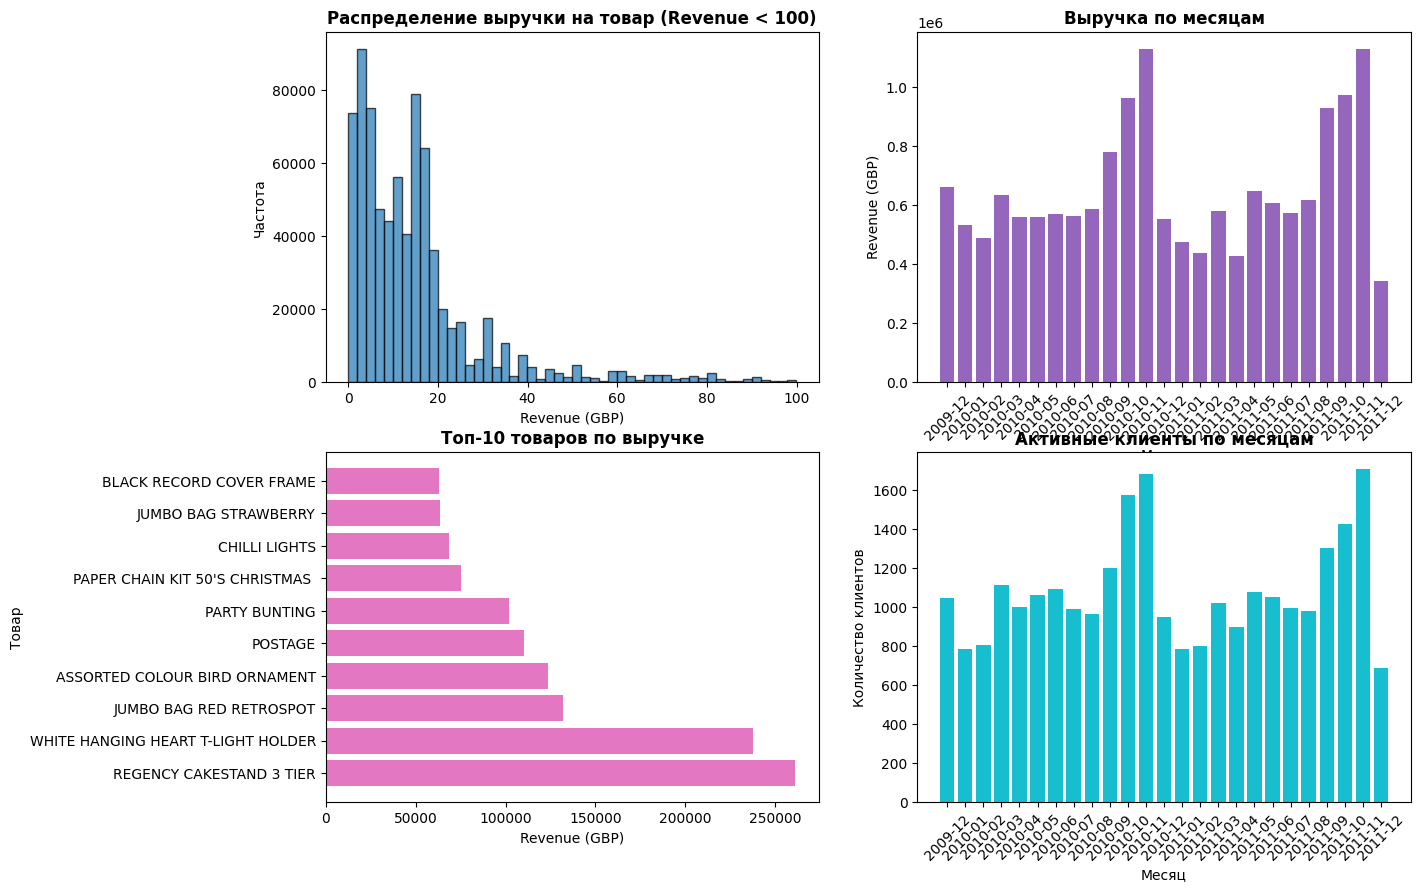

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

revenue_pos = df_customer[df_customer['Revenue'] > 0]['Revenue']
axes[0, 0].hist(revenue_pos[revenue_pos < 100], bins=50, color='#1f77b4', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение выручки на товар (Revenue < 100)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Revenue (GBP)')
axes[0, 0].set_ylabel('Частота')

monthly_revenue = df_customer.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth_str'] = monthly_revenue['YearMonth'].astype(str)
axes[0, 1].bar(monthly_revenue['YearMonth_str'], monthly_revenue['Revenue'], color='#9467bd')
axes[0, 1].set_title('Выручка по месяцам', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Revenue (GBP)')
axes[0, 1].tick_params(axis='x', rotation=45)


top_products = df_customer.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
axes[1, 0].barh(top_products.index, top_products.values, color='#e377c2')
axes[1, 0].set_title('Топ-10 товаров по выручке', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Revenue (GBP)')
axes[1, 0].set_ylabel('Товар')

customers_by_month = df_customer.groupby('YearMonth')['Customer ID'].nunique()
axes[1, 1].bar(customers_by_month.index.astype(str), customers_by_month.values, color='#17becf')
axes[1, 1].set_title('Активные клиенты по месяцам', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('Количество клиентов')
axes[1, 1].tick_params(axis='x', rotation=45)


Большинство товаров стоят до 20$ => магазин торгует недорогими товарами.
В списке лидеров — преимущественно декор, новогодние товары и аксессуары (подсвечники, гирлянды, бумажные цепи). Это говорит о ярко выраженной сезонности: пик продаж, скорее всего, приходится на ноябрь-декабрь.

  YearMonth  Net_Revenue  Total_Orders  Total_Customers         AOV  \
0   2009-12   660125.100          1900             1045  347.434263   
1   2010-01   530436.512          1296              786  409.287432   
2   2010-02   487596.426          1333              805  365.788767   
3   2010-03   633419.311          1907             1111  332.154856   
4   2010-04   558007.832          1615              998  345.515685   

   Revenue_per_Customer  Orders_per_Customer  
0            631.698660             1.818182  
1            674.855613             1.648855  
2            605.709846             1.655901  
3            570.134393             1.716472  
4            559.126084             1.618236  


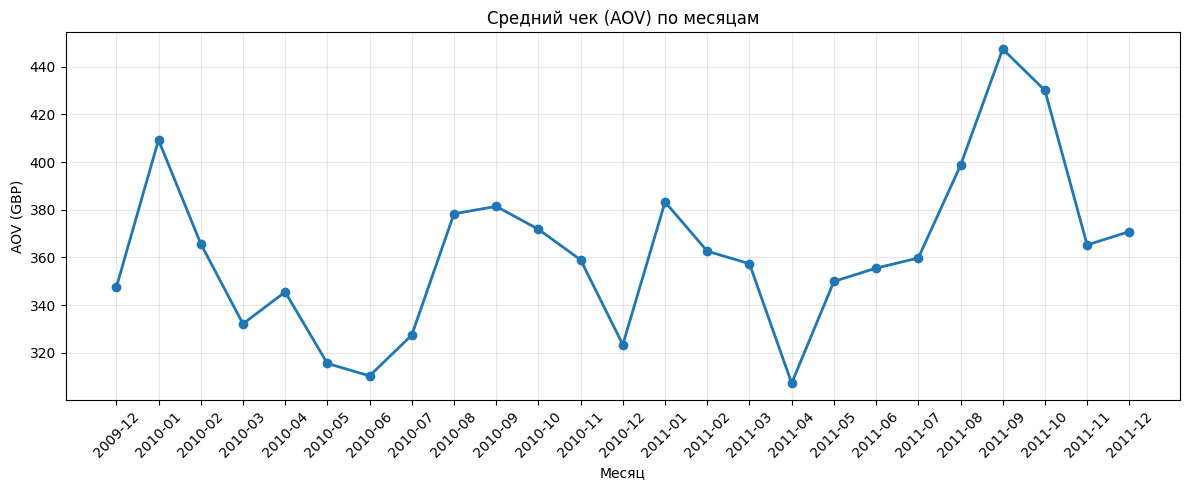

Средний чек: 362
Среднее количество заказов в месяц: 1795
Среднее количество клиентов в месяц: 1080


In [20]:
monthly = df_customer[df_customer['Price'] > 0].groupby('YearMonth').agg(
    Net_Revenue = ('Revenue', 'sum'),
    Total_Orders = ('Invoice', 'nunique'),
    Total_Customers = ('Customer ID', 'nunique') 
).reset_index()

monthly['AOV'] = monthly['Net_Revenue'] / monthly['Total_Orders']
monthly['Revenue_per_Customer'] = monthly['Net_Revenue'] / monthly['Total_Customers']
monthly['Orders_per_Customer'] = monthly['Total_Orders'] / monthly['Total_Customers']
print(monthly.head())
plt.figure(figsize=(12, 5))
plt.plot(monthly['YearMonth'].astype(str), monthly['AOV'], marker='o', linewidth=2)
plt.title('Средний чек (AOV) по месяцам')
plt.xlabel('Месяц')
plt.ylabel('AOV (GBP)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Средний чек: {monthly['AOV'].mean():.0f}')
print(f'Среднее количество заказов в месяц: {monthly['Total_Orders'].mean():.0f}')
print(f'Среднее количество клиентов в месяц: {monthly['Total_Customers'].mean():.0f}')

График AOV показывает сильные колебания без устойчивого тренда. Подверждается гипотеза о том, что пик продаж приходится на предновогодние месяца.

# 4. Когортный анализ

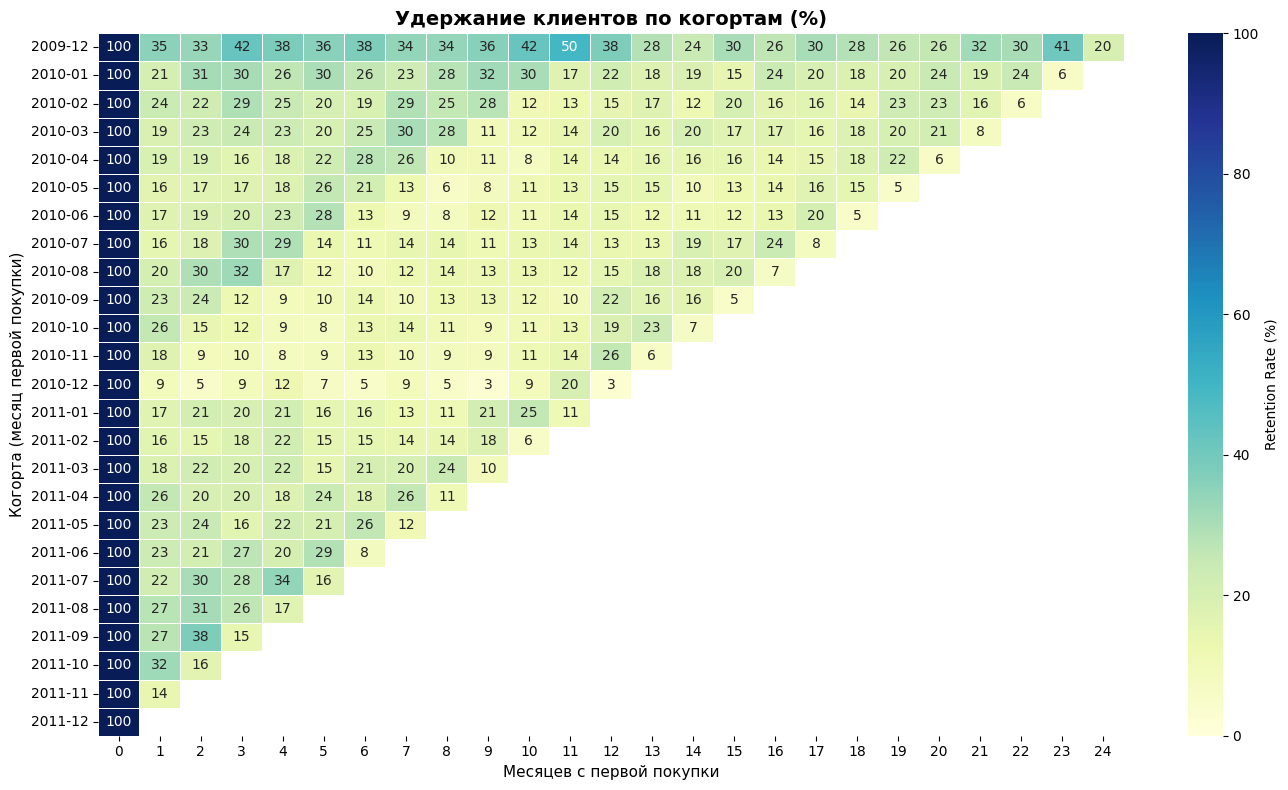

In [21]:
cohort_base = df_customer[(df_customer['Quantity'] > 0) & (df_customer['Price'] > 0)].copy()
cohort_base['InvoiceMonth'] = cohort_base['InvoiceDate'].dt.to_period('M')
cohort_data = cohort_base.groupby('Customer ID')['InvoiceMonth'].min().reset_index()
cohort_data.columns = ['Customer ID', 'CohortMonth']

df_cohort = cohort_base.merge(cohort_data, on='Customer ID')
df_cohort['CohortIndex'] = (
    df_cohort['InvoiceMonth'].astype(int) - df_cohort['CohortMonth'].astype(int)
)
cohort_counts = (df_cohort.groupby(['CohortMonth', 'CohortIndex'])['Customer ID']
                 .nunique()
                 .reset_index())

cohort_pivot = cohort_counts.pivot_table(index='CohortMonth', 
                                          columns='CohortIndex', 
                                          values='Customer ID')

cohort_size = cohort_pivot[0]
retention_matrix = (cohort_pivot.divide(cohort_size, axis=0) * 100).round(1)

plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix,
            annot=True,
            fmt='.0f',
            cmap='YlGnBu',
            linewidths=0.5,
            linecolor='white',
            vmin=0,
            vmax=100,
            cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Удержание клиентов по когортам (%)', fontsize=14, fontweight='bold')
plt.xlabel('Месяцев с первой покупки', fontsize=11)
plt.ylabel('Когорта (месяц первой покупки)', fontsize=11)
plt.tight_layout()
plt.show()

In [22]:
weighted_retention = (retention_matrix.mul(cohort_size, axis=0).sum(axis=0) / cohort_size.sum()).dropna()
retention_summary = pd.DataFrame({
    'Месяц жизни': weighted_retention.index.astype(int),
    'Удержание (%)': weighted_retention.values.round(1)
})
print(retention_summary.head(12).to_string(index=False))
print("\nКлючевые точки удержания:")
for month in [1, 3, 6, 12]:
    if month in weighted_retention.index:
        print(f'Через {month} месяц(ев): {weighted_retention.loc[month]:.1f}% клиентов остаются')

 Месяц жизни  Удержание (%)
           0          100.0
           1           23.0
           2           22.4
           3           22.7
           4           20.3
           5           19.0
           6           18.7
           7           17.9
           8           16.1
           9           15.3
          10           14.9
          11           16.2

Ключевые точки удержания:
Через 1 месяц(ев): 23.0% клиентов остаются
Через 3 месяц(ев): 22.7% клиентов остаются
Через 6 месяц(ев): 18.7% клиентов остаются
Через 12 месяц(ев): 16.5% клиентов остаются


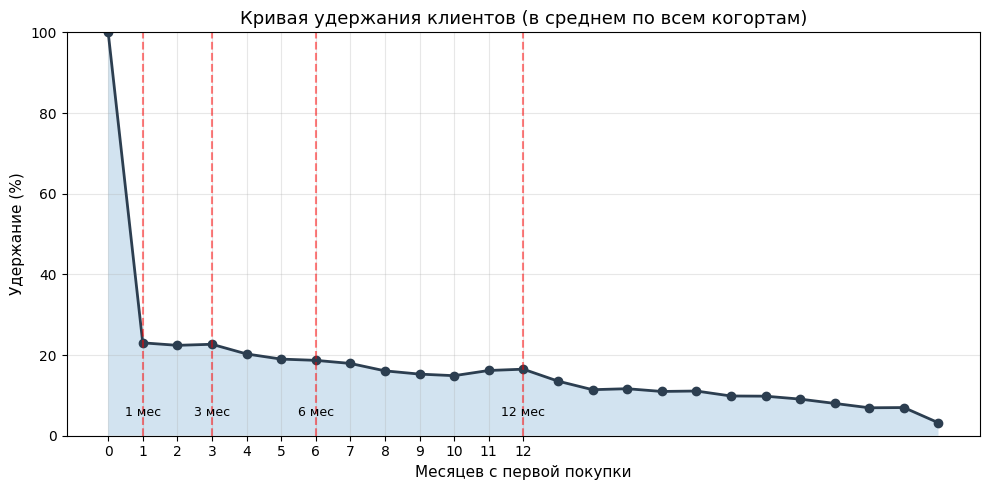

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(weighted_retention.index, weighted_retention.values, 
         marker='o', linewidth=2, color='#2c3e50')
plt.fill_between(weighted_retention.index, weighted_retention.values, alpha=0.2)
plt.title('Кривая удержания клиентов (в среднем по всем когортам)', fontsize=13)
plt.xlabel('Месяцев с первой покупки', fontsize=11)
plt.ylabel('Удержание (%)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 13))
plt.ylim(0, 100)
for month in [1, 3, 6, 12]:
    if month in weighted_retention.index:
        plt.axvline(x=month, linestyle='--', alpha=0.5, color='red')
        plt.text(month, 5, f'{month} мес', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

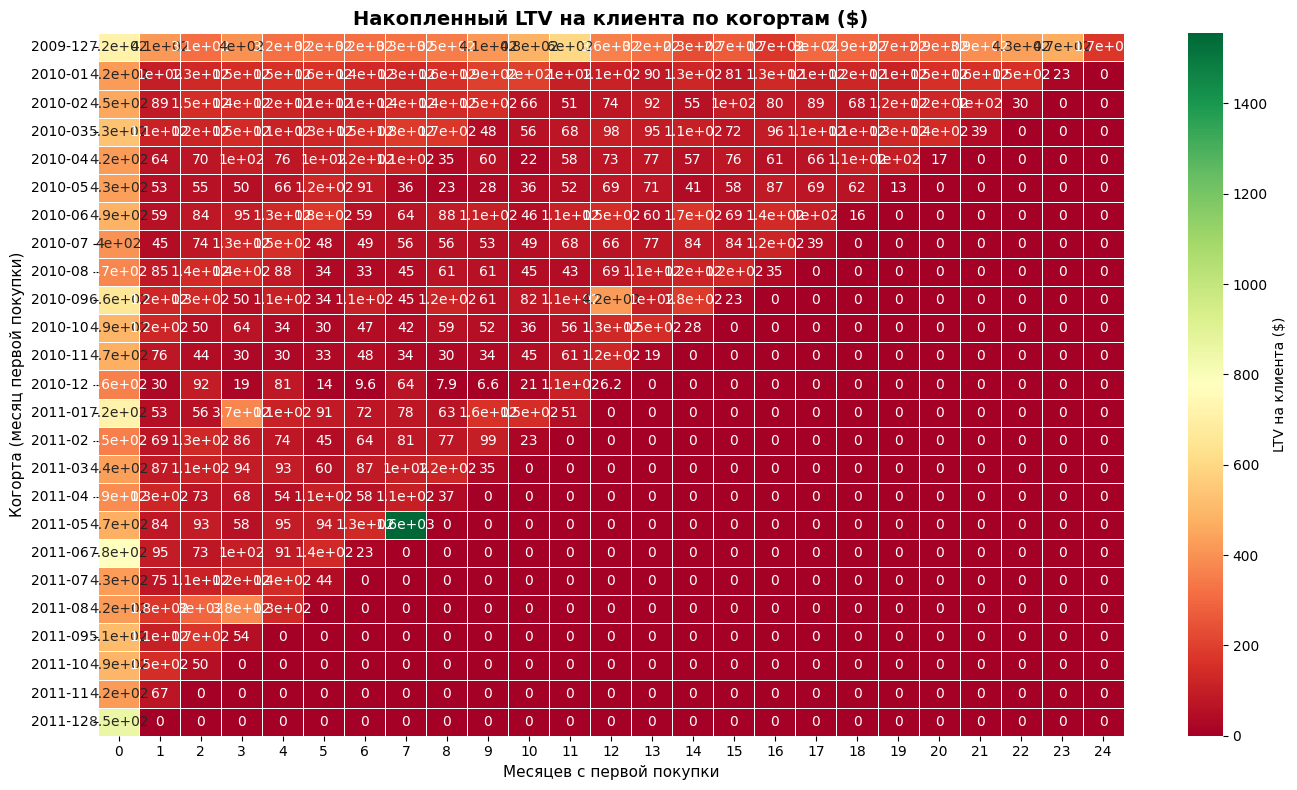

In [24]:
ltv_data = df_cohort.groupby(['CohortMonth', 'CohortIndex'])['Revenue'].sum().reset_index()
ltv_pivot = ltv_data.pivot_table(index='CohortMonth', 
                                  columns='CohortIndex', 
                                  values='Revenue',
                                  fill_value=0)

ltv_per_customer = ltv_pivot.divide(cohort_size, axis=0).round(2)
plt.figure(figsize=(14, 8))
sns.heatmap(ltv_per_customer,
            annot=True,
            cmap='RdYlGn',
            linewidths=0.5,
            linecolor='white',
            vmin=0,
            cbar_kws={'label': 'LTV на клиента ($)'})
plt.title('Накопленный LTV на клиента по когортам ($)', fontsize=14, fontweight='bold')
plt.xlabel('Месяцев с первой покупки', fontsize=11)
plt.ylabel('Когорта (месяц первой покупки)', fontsize=11)
plt.tight_layout()
plt.show()

In [25]:
weighted_ltv = (ltv_per_customer.mul(cohort_size, axis=0).sum(axis=0) / cohort_size.sum()).dropna()
ltv_summary = pd.DataFrame({
    'Месяц жизни': weighted_ltv.index.astype(int),
    'Накопленный LTV ($)': weighted_ltv.values.round(2)
})
print(ltv_summary.head(12).to_string(index=False))
print('\nключевые точки LTV:')
for month in [1, 3, 6, 12]:
    if month in weighted_ltv.index:
        print(f'Через {month} месяц(ев): ${weighted_ltv.loc[month]:.2f} накопленного LTV')

 Месяц жизни  Накопленный LTV ($)
           0               514.21
           1               143.62
           2               131.23
           3               146.16
           4               122.31
           5               115.82
           6               112.19
           7               141.37
           8               116.25
           9               117.55
          10               118.12
          11               139.32

ключевые точки LTV:
Через 1 месяц(ев): $143.62 накопленного LTV
Через 3 месяц(ев): $146.16 накопленного LTV
Через 6 месяц(ев): $112.19 накопленного LTV
Через 12 месяц(ев): $128.14 накопленного LTV


In [26]:
if len(ltv_per_customer) >= 2:
    if 3 in ltv_per_customer.columns:
        ltv_3m = ltv_per_customer[3].sort_values(ascending=False)
        best_cohort_ltv = ltv_3m.index[0]
        worst_cohort_ltv = ltv_3m.index[-1]
        
        print(f'\nЛучшая когорта по LTV на 3-й месяц: {best_cohort_ltv}')
        print(f'LTV = ${ltv_per_customer.loc[best_cohort_ltv, 3]:.2f} на клиента')
        
        print(f'\nХудшая когорта по LTV на 3-й месяц: {worst_cohort_ltv}')
        print(f'LTV = ${ltv_per_customer.loc[worst_cohort_ltv, 3]:.2f} на клиента')
    


Лучшая когорта по LTV на 3-й месяц: 2009-12
LTV = $396.51 на клиента

Худшая когорта по LTV на 3-й месяц: 2011-12
LTV = $0.00 на клиента


# 5. Выводы

Когортный анализ показал, что 77% клиентов отваливаются после первой покупки, что ожидаемо, поскольку магазин специализируется на новогодних товарах. LTV почти не растёт после первого месяца — основные деньги клиенты приносят сразу.

Рекомендуется сосредоточить бюджет на удержании в первый месяц (welcome-кампании, промокод на второй заказ) и отдельно работать над монетизацией лояльной аудитории (программа лояльности, персонализация).

Также в качестве рекомендации предлагается расширить ассртиммент магазина и предлагать товары не только к новогодним/рождественским праздникам, а и в межсезон.